<a href="https://colab.research.google.com/github/farrelrassya/IntroductionMachineLearningwithpython/blob/main/03.3_Dimensionality_Reduction_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 3 - Teknik Reduksi Dimensi (Dimensionality Reduction Techniques)

Notebook ini berisi hasil replikasi kode, latihan, dan penjelasan detail dari **Chapter 3 Dimensionality Reduction Techniques** pada buku *scikit-learn Cookbook, Third Edition*. Seluruh materi penjelasan teoretis telah diterjemahkan dan diperluas dalam **Bahasa Indonesia** secara mendalam.

## Analisis Komponen Utama (PCA)

PCA adalah teknik Dimensionality Reduction *tanpa pengawasan* yang mengubah data berdimensi tinggi menjadi sistem koordinat baru dengan sumbu (komponen utama) diurutkan berdasarkan jumlah varians yang dijelaskannya.

### Konsep Utama:
- PCA menemukan arah varian maksimum dalam data
- Komponennya ortogonal satu sama lain
- Komponen pertama menjelaskan varians terbanyak, diikuti komponen kedua, dan seterusnya.
- Membutuhkan data standar untuk hasil yang optimal

### Bersiap
Untuk memulai, kami akan memuat kumpulan data mainan kami dari scikit-learn. Scikit-learn versi 1.5 berisi 6 kumpulan data yang umum digunakan untuk mengilustrasikan berbagai langkah dan fitur ML di perpustakaan. Dalam hal ini, kita akan menggunakan dataset Wine.

In [1]:
# Memuat perpustakaan
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
import warnings

# Tetapkan benih acak untuk reproduktifitas dan menekan peringatan
np.random.seed(2024)
warnings.simplefilter(action='ignore', category=FutureWarning)

# Muat kumpulan data
wine = load_wine()
df_wine = pd.DataFrame(data=wine.data, columns=wine.feature_names)
target_wine = wine.target
display(df_wine.head(10))

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0


### Bagaimana cara melakukannya...

Kami akan memuat beberapa perpustakaan tambahan dari scikit-learn serta Matplotlib yang merupakan perpustakaan Python yang umum digunakan untuk visualisasi data. Anda juga akan melihat bahwa kami menggunakan kelas `Pipeline()` untuk merangkai langkah prapemrosesan penskalaan data dengan PCA. Ini akan menjadi konvensi rutin dalam buku ini, jadi sebaiknya Anda merasa nyaman dengannya!

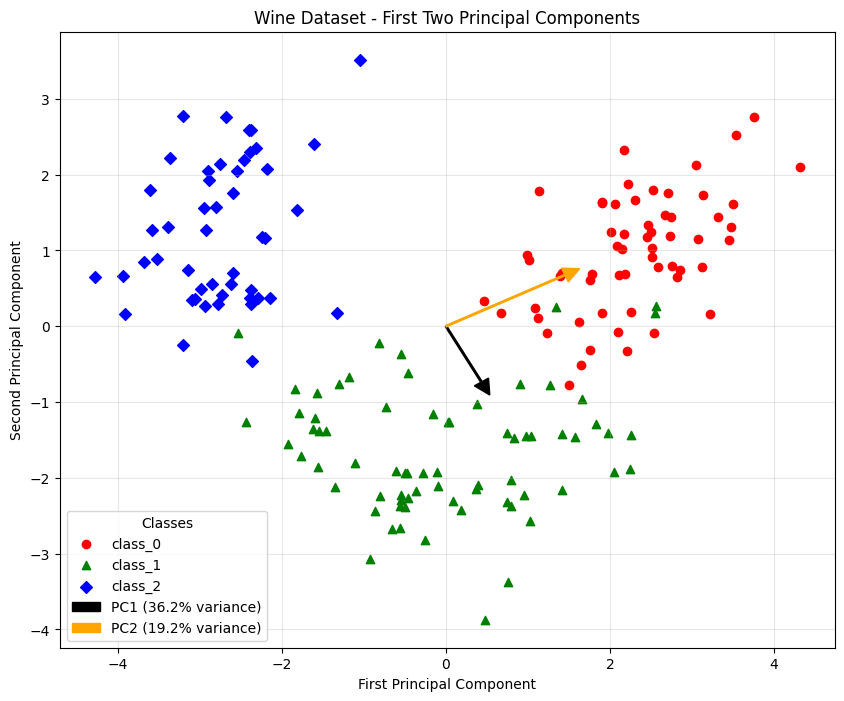

In [2]:
# Memuat perpustakaan
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Buat alur untuk PCA
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Always scale before PCA
    ('pca', PCA(n_components=2))   # Reduce to 2 dimensions
])

# Cocokkan dan ubah data
X_pca = pca_pipeline.fit_transform(df_wine)

# Visualisasikan data yang diubah
plt.figure(figsize=(10, 8))
shapes = ['o', '^', 'D']
colors = ['r', 'g', 'b']

# Plot titik-titik pencarnya
for i, (shape, color) in enumerate(zip(shapes, colors)):
    plt.scatter(X_pca[target_wine == i, 0], X_pca[target_wine == i, 1], 
                c=color, marker=shape, label=wine.target_names[i])

# Dapatkan komponen PCA dan plot sebagai vektor
pca = pca_pipeline.named_steps['pca']
origin = np.zeros(2)  # Origin point for vectors
arrow_colors = ['black', 'orange']

# Skalakan komponen berdasarkan rasio varians yang dijelaskan untuk visualisasi yang lebih baik
scaling = 3
for i, (component, ratio) in enumerate(zip(pca.components_, pca.explained_variance_ratio_)):
    plt.arrow(origin[0], origin[1],
              component[0] * scaling, component[1] * scaling,
              color=arrow_colors[i],
              width=0.02, head_width=0.2, head_length=0.2,
              label=f'PC{i+1} ({ratio:.1%} variance)')

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Wine Dataset - First Two Principal Components')
plt.legend(title="Classes")
plt.grid(True, alpha=0.3)
plt.show()

### Cara kerjanya...

PCA bekerja dengan mengidentifikasi arah (komponen utama) di mana datanya paling bervariasi. Komponen-komponen ini merupakan kombinasi linier dari fitur aslinya dan bersifat ortogonal (yaitu tegak lurus) satu sama lain.

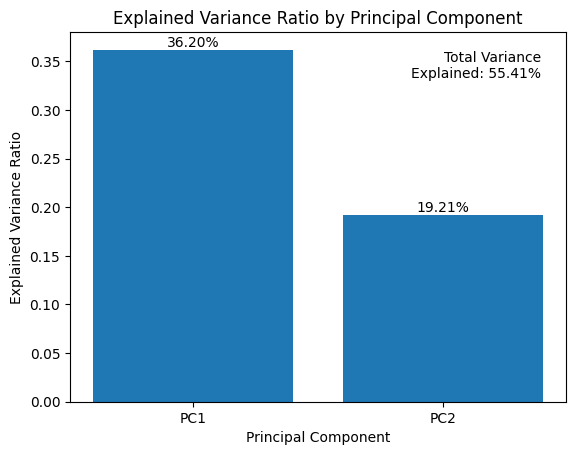

In [3]:
# Dapatkan rasio varians yang dijelaskan
pca = pca_pipeline.named_steps['pca']
explained_variance_ratio = pca.explained_variance_ratio_

# Hitung varians kumulatif
cumulative_variance = np.sum(explained_variance_ratio)

# Diagram batang plot
fig, ax = plt.subplots()

x = np.arange(1, len(explained_variance_ratio) + 1)
y = explained_variance_ratio
bars = ax.bar(x, y)

# Tambahkan label persentase pada batang
for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.2%}',
                        ha='center', va='bottom')

# Tambahkan teks varians kumulatif di kanan atas
ax.text(0.95, 0.95, f'Total Variance\nExplained: {cumulative_variance:.2%}',
                transform=ax.transAxes,
                ha='right', va='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Tetapkan label sumbu x khusus untuk dua komponen utama
ax.set_xticks(x)
ax.set_xticklabels(['PC1', 'PC2'])

ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

1. Baris Teratas: Fitur Standar Asli. Dua plot sebar pertama menampilkan pasangan fitur standar asli sebelum PCA: "Alkohol vs. Asam Malat" di sebelah kiri dan "Flavanoids vs. Proanthocyanin" di sebelah kanan. Setiap titik data diberi kode warna berdasarkan kelas wine (kelas_0, kelas_1, kelas_2), dengan penanda berbeda untuk setiap kelas. Distribusi menunjukkan tumpang tindih dan pemisahan antar kelas dalam ruang fitur mentah.
2. Baris Bawah: Fitur Transformasi PCA. Baris bawah menunjukkan fitur yang sama yang ditransformasikan menggunakan PCA, di mana data diorientasikan ulang sepanjang dua komponen utama pertama (PC1 dan PC2). Panah menunjukkan arah PC1 dan PC2, yang menangkap varians maksimum dalam data. PCA membantu memisahkan kelas wine dengan lebih baik dengan memproyeksikan fitur ke dalam ruang berdimensi lebih rendah dengan perbedaan kelas yang lebih baik.

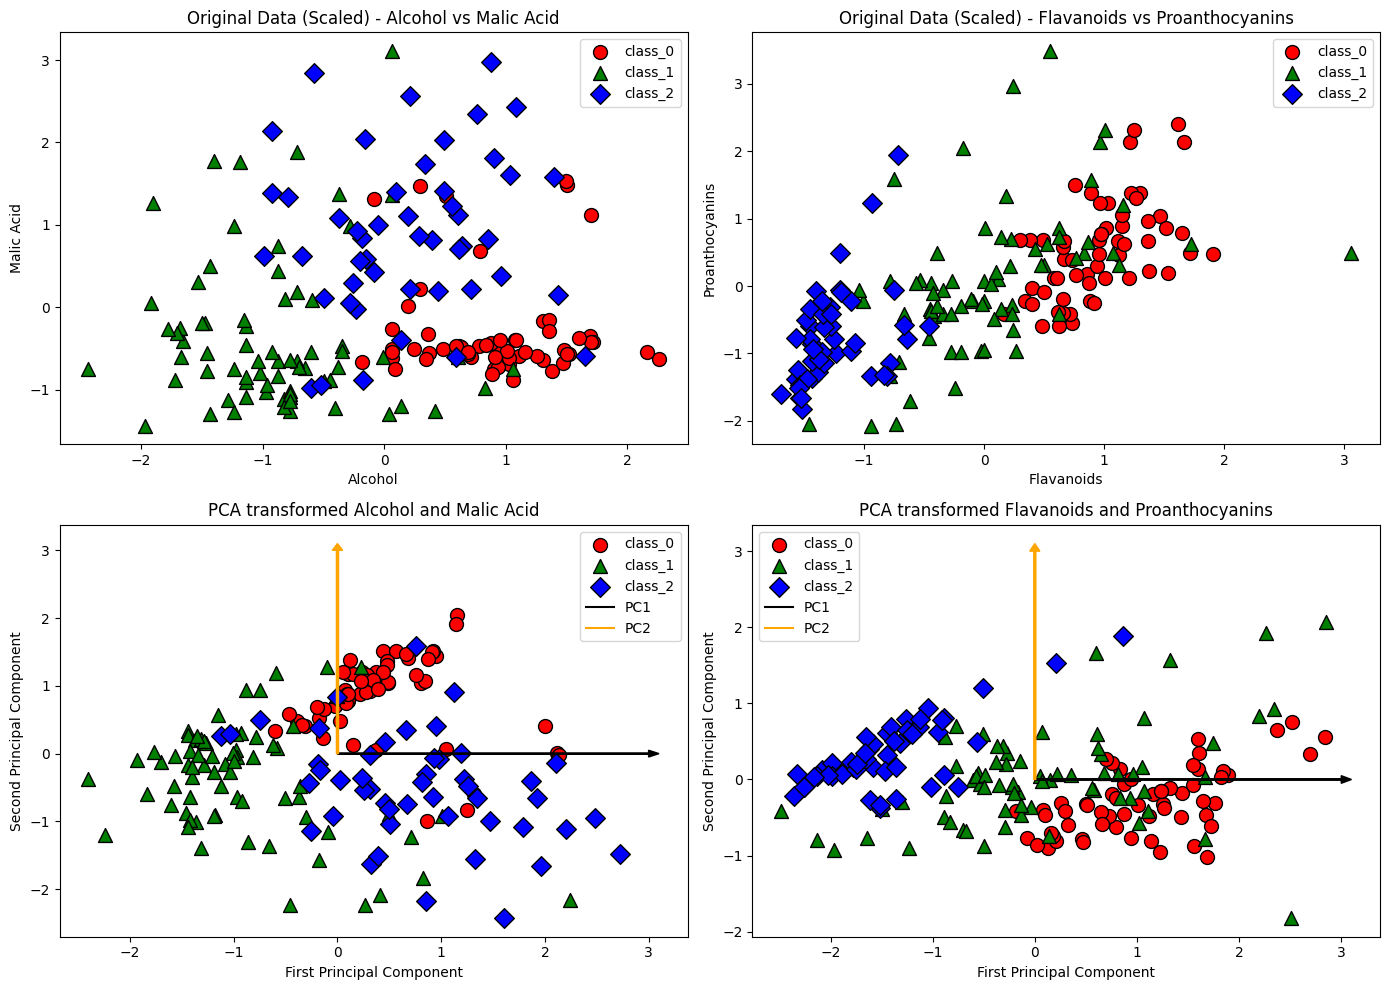

In [4]:
# Pilih dua fitur: 'alcohol' dan 'malic_acid'
features_1 = ['alcohol', 'malic_acid']
df_wine_subset_1 = df_wine[features_1]
df_wine_subset_1 = pd.DataFrame(StandardScaler().fit_transform(df_wine_subset_1), columns=features_1)

# Lakukan PCA pada kedua fitur tersebut
pca_2d_1 = PCA(n_components=2)
X_pca_2d_1 = pca_2d_1.fit_transform(df_wine_subset_1)

# Pilih dua fitur berbeda: 'flavanoid' dan 'proanthocyanin'
features_2 = ['flavanoids', 'proanthocyanins']
df_wine_subset_2 = df_wine[features_2]
df_wine_subset_2 = pd.DataFrame(StandardScaler().fit_transform(df_wine_subset_2), columns=features_2)

# Lakukan PCA pada dua fitur berbeda
pca_2d_2 = PCA(n_components=2)
X_pca_2d_2 = pca_2d_2.fit_transform(df_wine_subset_2)

# Buat gambar dengan empat subplot dalam kotak 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot data asli 1 (kiri atas)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = target_wine == i
    axes[0,0].scatter(df_wine_subset_1['alcohol'][mask],
                     df_wine_subset_1['malic_acid'][mask],
                     marker=shape, c=color, edgecolor='k', s=100,
                     label=wine.target_names[i])
axes[0,0].set_xlabel('Alcohol')
axes[0,0].set_ylabel('Malic Acid')
axes[0,0].set_title('Original Data (Scaled) - Alcohol vs Malic Acid')
axes[0,0].legend()

# Plot data asli 2 (kanan atas)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = target_wine == i
    axes[0,1].scatter(df_wine_subset_2['flavanoids'][mask],
                     df_wine_subset_2['proanthocyanins'][mask],
                     marker=shape, c=color, edgecolor='k', s=100,
                     label=wine.target_names[i])
axes[0,1].set_xlabel('Flavanoids')
axes[0,1].set_ylabel('Proanthocyanins')
axes[0,1].set_title('Original Data (Scaled) - Flavanoids vs Proanthocyanins')
axes[0,1].legend()

# PCA plot 1 (kiri bawah)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = target_wine == i
    axes[1,0].scatter(X_pca_2d_1[mask, 0], 
                     X_pca_2d_1[mask, 1],
                     marker=shape, c=color, edgecolor='k', s=100,
                     label=wine.target_names[i])
axes[1,0].set_xlabel('First Principal Component')
axes[1,0].set_ylabel('Second Principal Component')
axes[1,0].set_title('PCA transformed Alcohol and Malic Acid')

# Plot komponen utama sebagai vektor untuk plot PCA pertama
origin_1 = np.zeros(2)
components_1 = np.eye(2)
arrow_colors_1 = ['black', 'orange']
scaling = 3
for i, component in enumerate(components_1):
    axes[1,0].arrow(origin_1[0], origin_1[1], component[0] * scaling, component[1] * scaling,
                    color=arrow_colors_1[i], width=0.02, head_width=0.1, head_length=0.1)
    axes[1,0].plot([], [], color=arrow_colors_1[i], label=f'PC{i+1}')

axes[1,0].legend()

# PCA plot 2 (kanan bawah)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = target_wine == i
    axes[1,1].scatter(X_pca_2d_2[mask, 0],
                     X_pca_2d_2[mask, 1],
                     marker=shape, c=color, edgecolor='k', s=100,
                     label=wine.target_names[i])
axes[1,1].set_xlabel('First Principal Component')
axes[1,1].set_ylabel('Second Principal Component')
axes[1,1].set_title('PCA transformed Flavanoids and Proanthocyanins')

# Plot komponen utama sebagai vektor untuk plot PCA kedua
origin_2 = np.zeros(2)
components_2 = np.eye(2)
for i, component in enumerate(components_2):
    axes[1,1].arrow(origin_2[0], origin_2[1], component[0] * scaling, component[1] * scaling,
                    color=arrow_colors_1[i], width=0.02, head_width=0.1, head_length=0.1)
    axes[1,1].plot([], [], color=arrow_colors_1[i], label=f'PC{i+1}')

axes[1,1].legend()

plt.tight_layout()
plt.show()

### Praktik Terbaik untuk PCA:
1. Selalu skalakan data Anda sebelum menerapkan PCA
2. Periksa rasio varians yang dijelaskan untuk menentukan jumlah komponen
3. Gunakan PCA untuk:
   - Pengurangan dimensi
   - Ekstraksi fitur
   - Visualisasi data
   
### Kesalahan Umum:
- Tidak menskalakan data sebelum PCA
- Menggunakan PCA ketika interpretabilitas itu penting
- Menyimpan terlalu sedikit atau terlalu banyak komponen

## Analisis Diskriminan Linier (LDA)

LDA adalah teknik Dimensionality Reduction *yang diawasi* yang menemukan kombinasi fitur linier yang paling baik dalam memisahkan kelas.

### Konsep Utama:
- Memaksimalkan keterpisahan kelas
- Dapat digunakan untuk Dimensionality Reduction dan klasifikasi
- Mempertimbangkan label kelas (diawasi)

### Bersiap
Kami akan menggunakan dataset Wine yang sama dengan yang digunakan sebelumnya, jadi kami tidak perlu memuatnya lagi.

### Bagaimana cara melakukannya...

Seperti yang kita lihat dengan PCA, LDA hanya perlu memuat satu kelas scikit-learn untuk menjalankannya pada kumpulan data Anda. Kami juga akan menggunakan kelas `Pipeline()` untuk merangkai penskalaan kami sebelum menerapkan LDA.

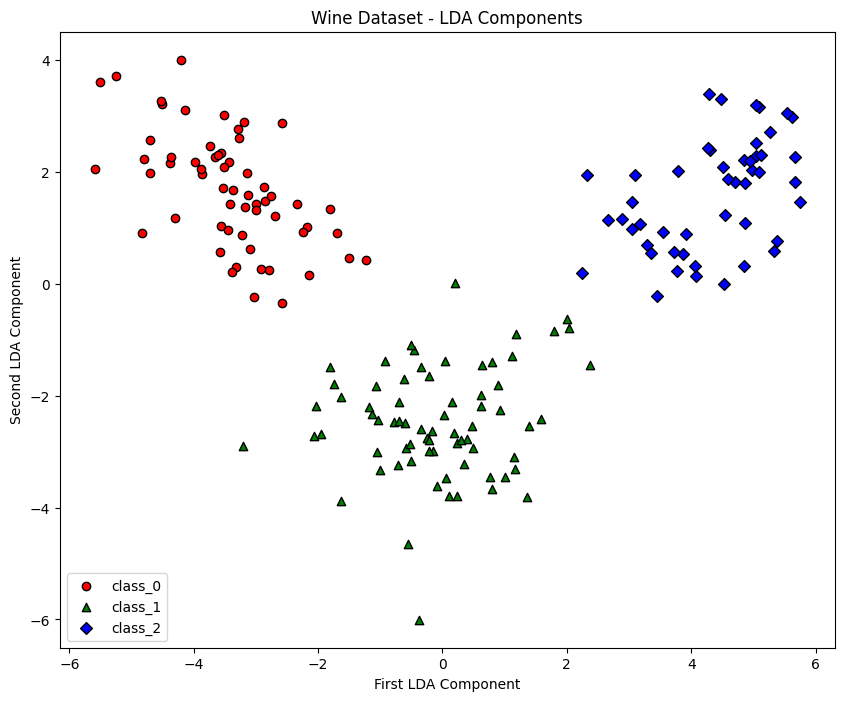

In [5]:
# Memuat perpustakaan
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Pisahkan kumpulan data anggur berdasarkan fitur dan target
X_wine, y_wine = wine.data, wine.target

# Buat saluran LDA untuk kumpulan data anggur
lda_pipeline_wine = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(n_components=2))  # min(n_features, n_classes - 1) for wine dataset is 2
])

# Sesuaikan dan ubah data anggur
X_lda_wine = lda_pipeline_wine.fit_transform(X_wine, y_wine)

# Visualisasikan transformasi LDA untuk kumpulan data anggur
plt.figure(figsize=(10, 8))

# Tentukan penanda dan warna untuk setiap kelas
shapes = ['o', '^', 'D']
colors = ['r', 'g', 'b']

# Plot setiap kelas dengan spidol dan warna yang berbeda
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = y_wine == i
    plt.scatter(X_lda_wine[mask, 0], X_lda_wine[mask, 1],
               c=color, marker=shape, edgecolor='black',
               label=wine.target_names[i])

plt.xlabel('First LDA Component')
plt.ylabel('Second LDA Component')
plt.title('Wine Dataset - LDA Components')
plt.legend()
plt.show()

### Cara kerjanya...

LDA adalah teknik terbimbing yang berupaya menemukan kombinasi fitur linier yang paling baik memisahkan dua kelas atau lebih. Meskipun PCA dan LDA digunakan untuk Dimensionality Reduction, keduanya memiliki tujuan dan metodologi yang berbeda. Saat divisualisasikan, tampilan PCA dan LDA bisa serupa tergantung pada kumpulan data yang diterapkan.

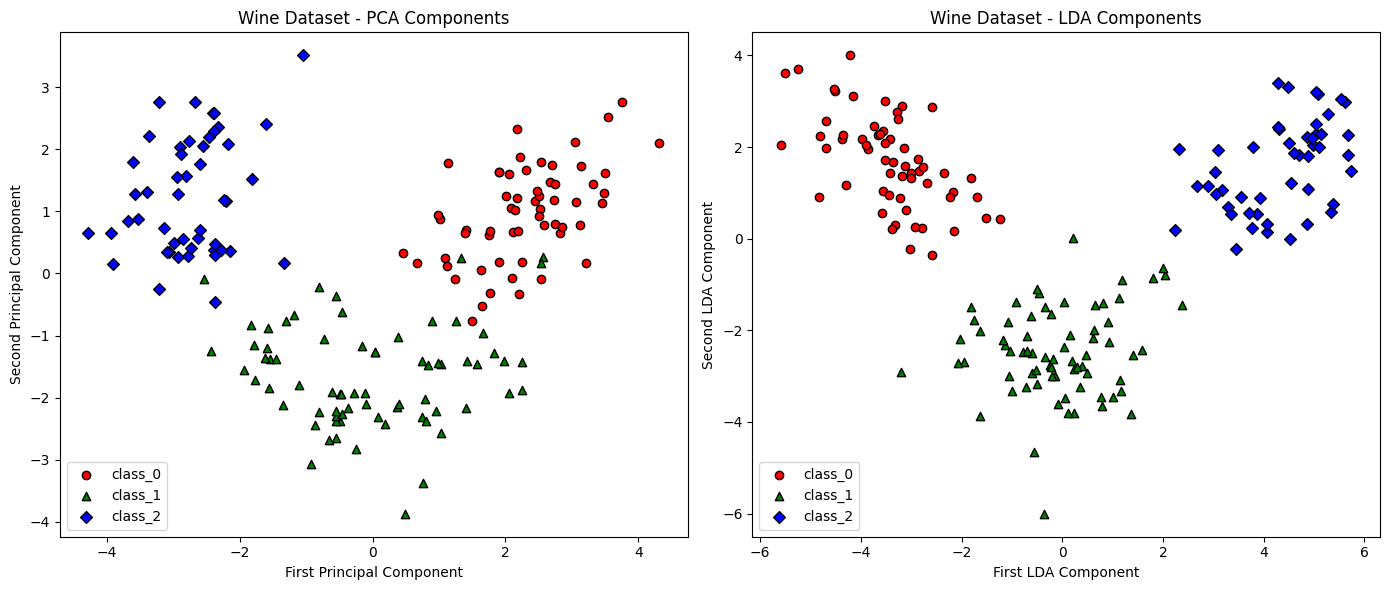

In [6]:
# Buat plot berdampingan
plt.figure(figsize=(14, 6))

plt.subplot(121)
shapes = ['o', '^', 'D'] 
colors = ['r', 'g', 'b']

for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = y_wine == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, marker=shape, edgecolor='black',
               label=wine.target_names[i])

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Wine Dataset - PCA Components')
plt.legend()

plt.subplot(122)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = y_wine == i
    plt.scatter(X_lda_wine[mask, 0], X_lda_wine[mask, 1],
               c=color, marker=shape, edgecolor='black',
               label=wine.target_names[i])

plt.xlabel('First LDA Component')
plt.ylabel('Second LDA Component')
plt.title('Wine Dataset - LDA Components')
plt.legend()

plt.tight_layout()
plt.show()

### Praktik Terbaik untuk LDA:
1. Skalakan fitur sebelum menerapkan LDA
2. Gunakan ketika pemisahan kelas penting
3. Periksa asumsi (distribusi normal, homoskedastisitas)

### Kesalahan Umum:
- Menggunakan LDA dengan kelas yang sangat tidak seimbang
- Menerapkan pada data yang berdistribusi tidak normal
- Menggunakan ketika kelas memiliki struktur kovarians yang sangat berbeda

## t-SNE untuk Visualisasi Data

t-SNE adalah teknik Dimensionality Reduction non-linier yang sangat cocok untuk visualisasi data berdimensi tinggi.

### Konsep Utama:
- Mempertahankan struktur data lokal
- Transformasi non-linier
- Sangat bagus untuk visualisasi

### Bersiap
Untuk demonstrasi t-SNE, kami akan menggunakan kumpulan data yang berbeda: kumpulan data pembelajaran mesin "terkenal" lainnya yang disebut **MNIST** yang terdiri dari gambar angka tulisan tangan 0-9. Dari Repositori Pembelajaran Mesin UCI: *"Kami menggunakan program pra-pemrosesan yang disediakan oleh NIST untuk mengekstrak bitmap digit tulisan tangan yang dinormalisasi dari formulir pracetak. Dari total 43 orang, 30 orang berkontribusi pada set pelatihan dan 13 orang berbeda pada set pengujian. Bitmap 32x32 dibagi menjadi blok-blok 4x4 yang tidak tumpang tindih dan jumlah piksel dihitung di setiap blok. Hal ini menghasilkan matriks masukan 8x8 yang setiap elemennya adalah bilangan bulat dalam rentang 0..16. Hal ini mengurangi dimensi dan memberikan invarian terhadap distorsi kecil."*

In [7]:
# Memuat perpustakaan
from sklearn.datasets import load_digits

# Muat kumpulan data
digits = load_digits()

### Bagaimana cara melakukannya...

Sekali lagi, kita akan menggunakan kelas Pipeline() untuk menerapkan penskalaan data secara berurutan sebelum t-SNE.

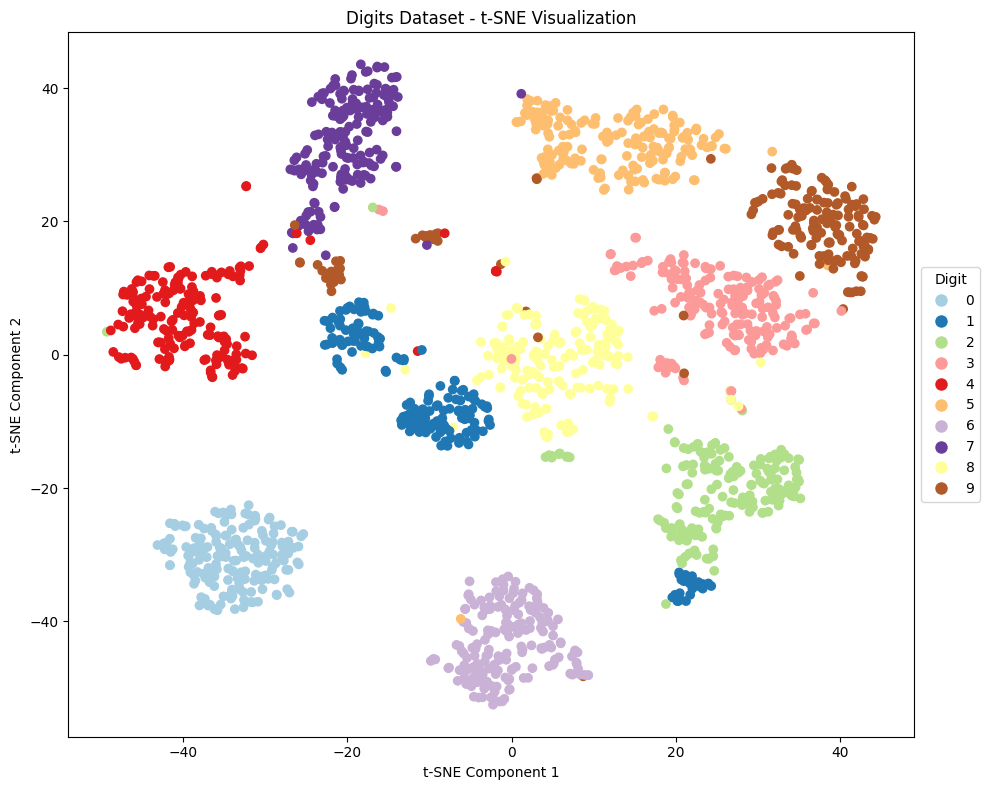

In [8]:
# Memuat perpustakaan
from sklearn.manifold import TSNE

# Buat pipa t-SNE
tsne_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('tsne', TSNE(n_components=2, random_state=2024))
])

# Cocokkan dan ubah data digit
X_tsne = tsne_pipeline.fit_transform(digits.data)
# Visualisasikan hasil t-SNE
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=digits.target, cmap='Paired', label=digits.target)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Digits Dataset - t-SNE Visualization')

# Buat legenda
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                             markerfacecolor=plt.cm.Paired(i/9), 
                             label=str(i), markersize=10)
                  for i in range(10)]
plt.legend(handles=legend_elements, title='Digit', loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

### Praktik Terbaik untuk t-SNE:
1. Skalakan data Anda sebelum menerapkan t-SNE
2. Bereksperimenlah dengan parameter kebingungan
3. Gunakan terutama untuk visualisasi

### Kesalahan Umum:
- Menggunakan t-SNE untuk pengurangan dimensi dalam pipa
- Menafsirkan struktur global secara berlebihan
- Tidak menyetel parameter kebingungan

## Latihan Praktis Pengurangan Dimensi

### Latihan 1: PCA dengan Logistic Regression
Bandingkan kinerja klasifikasi dengan dan tanpa PCA

In [9]:
# Memuat perpustakaan
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits

# Muat data digits
digits = load_digits()

# Pisahkan data
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=2024
)

# Pipa tanpa PCA
pipeline_no_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

# Pipa dengan PCA
pipeline_with_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),  # Keep 95% of variance
    ('clf', LogisticRegression(max_iter=1000))
])

# Cocokkan dan evaluasi kedua saluran pipa
pipeline_no_pca.fit(X_train, y_train)
pipeline_with_pca.fit(X_train, y_train)

# Hasil cetak
print("Accuracy without PCA:", 
      accuracy_score(y_test, pipeline_no_pca.predict(X_test)))
print("Accuracy with PCA:", 
      accuracy_score(y_test, pipeline_with_pca.predict(X_test)))


Accuracy without PCA: 0.975
Accuracy with PCA: 0.9638888888888889


### Latihan 2: t-SNE untuk Visualisasi Clustering
Visualisasikan seberapa baik t-SNE mempertahankan struktur cluster

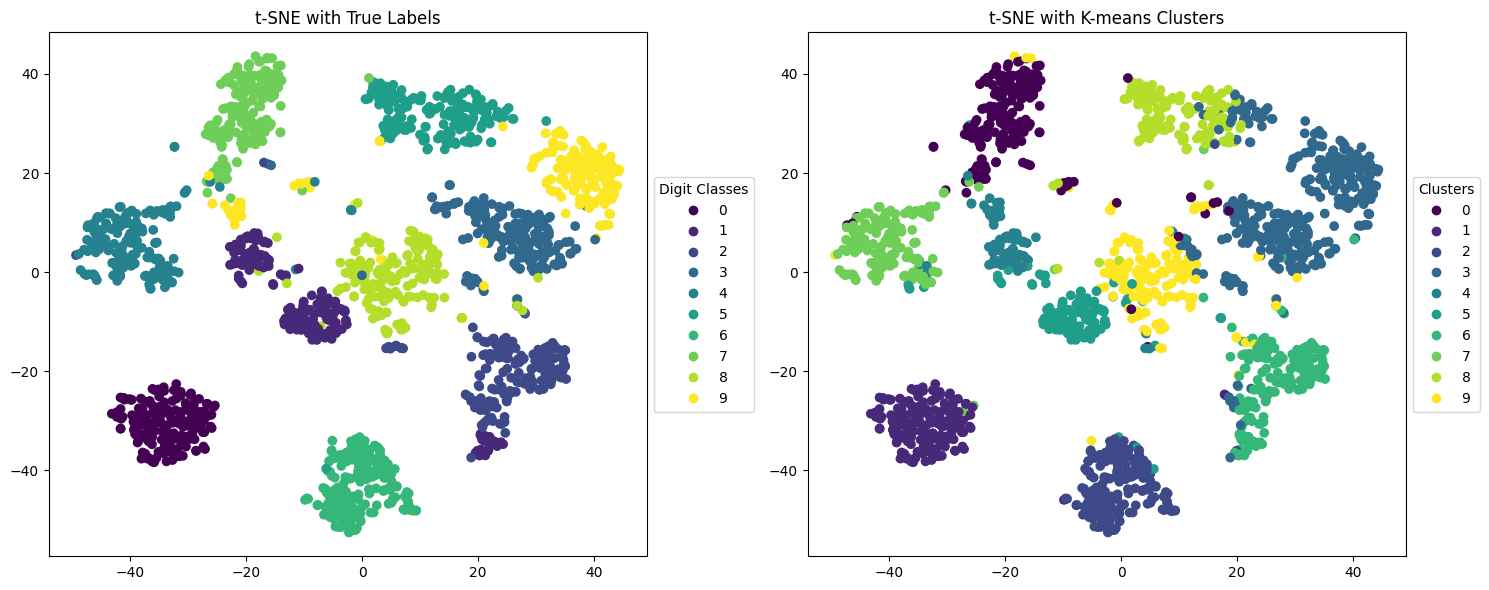

In [10]:
# Memuat perpustakaan
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits

# Muat data digits
digits = load_digits()

# Buat pipa t-SNE dan hitung X_tsne
tsne_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('tsne', TSNE(n_components=2, random_state=2024))
])
X_tsne = tsne_pipeline.fit_transform(digits.data)

# Terapkan Clustering K-means
kmeans = KMeans(n_clusters=10, random_state=2024)
cluster_labels = kmeans.fit_predict(digits.data)

# Buat plot berdampingan
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot menggunakan label yang sebenarnya
scatter1 = ax1.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                      c=digits.target, cmap='viridis')
ax1.set_title('t-SNE with True Labels')
legend1 = ax1.legend(*scatter1.legend_elements(),
                    title="Digit Classes",
                    loc="center left",
                    bbox_to_anchor=(1, 0.5))

# Plot menggunakan label cluster
scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                      c=cluster_labels, cmap='viridis')
ax2.set_title('t-SNE with K-means Clusters')
legend2 = ax2.legend(*scatter2.legend_elements(),
                    title="Clusters",
                    loc="center left", 
                    bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()


### Ringkasan dan Pandangan (Summary and Outlook)

#### 1. Ringkasan Bab
Dalam bab ini, kita telah mempelajari tiga teknik utama reduksi dimensi (*Dimensionality Reduction*):
* **Principal Component Analysis (PCA):** Pendekatan tanpa pengawasan (*unsupervised*) yang memproyeksikan data ke arah varians maksimum untuk menyederhanakan fitur tanpa target label.
* **Linear Discriminant Analysis (LDA):** Pendekatan terarah (*supervised*) yang memaksimalkan pemisahan antar kelas target, sangat berguna sebelum klasifikasi.
* **t-Distributed Stochastic Neighbor Embedding (t-SNE):** Teknik visualisasi non-linier yang sangat efektif untuk memetakan data berdimensi tinggi ke ruang 2D atau 3D agar mudah dipahami secara visual.

#### 2. Pandangan ke Depan
Reduksi dimensi membantu model berjalan lebih cepat dan menghindari efek buruk dari *curse of dimensionality*. Dengan data berdimensi rendah, pada **Bab 4** kita akan mulai membangun model machine learning prediktif berbasis jarak seperti k-Nearest Neighbors (k-NN) yang sangat sensitif terhadap dimensi fitur.